# CICIDS2017 and BoT-IoT Exploratory Data Analysis

This notebook compares class imbalance, correlations, traffic distributions, and attack-type breakdowns for both source datasets and their harmonized combined representation. Download both datasets into their configured raw directories before running all cells.

In [1]:
import sys
from pathlib import Path

sys.path.append('../src')

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from soc_ready_ids.config import load_config
from soc_ready_ids.data.loader import load_dataset
from soc_ready_ids.data.preprocessor import clean_label, infer_label_column

sns.set_theme(style='whitegrid')
config = load_config('../config.yaml')

DATASET_KEYS = {'CICIDS2017': 'cicids2017', 'BoT-IoT': 'bot-iot', 'Combined': 'combined'}

def label_for(name, frame):
    dataset_key = DATASET_KEYS[name]
    configured = config.get(f'data.label_columns.{dataset_key}', 'Label')
    return infer_label_column(frame, configured)

def load_for_eda(dataset_name):
    try:
        return load_dataset(config, dataset=dataset_name)
    except (FileNotFoundError, ValueError, KeyError) as exc:
        print(f'{dataset_name}: {exc}')
        return pd.DataFrame()

datasets = {
    'CICIDS2017': load_for_eda('cicids2017'),
    'BoT-IoT': load_for_eda('bot-iot'),
    'Combined': load_for_eda('combined'),
}
{name: frame.shape for name, frame in datasets.items()}

2026-07-27 01:27:01 | INFO | soc_ready_ids.data.loader | Loaded Benign-Monday-no-metadata.parquet with shape=(12500, 78)


2026-07-27 01:27:01 | INFO | soc_ready_ids.data.loader | Loaded Botnet-Friday-no-metadata.parquet with shape=(12500, 78)


2026-07-27 01:27:01 | INFO | soc_ready_ids.data.loader | Loaded Bruteforce-Tuesday-no-metadata.parquet with shape=(12500, 78)


2026-07-27 01:27:01 | INFO | soc_ready_ids.data.loader | Loaded DDoS-Friday-no-metadata.parquet with shape=(12500, 78)


2026-07-27 01:27:02 | INFO | soc_ready_ids.data.loader | Loaded DoS-Wednesday-no-metadata.parquet with shape=(12500, 78)


...

2026-07-27 01:27:06 | INFO | soc_ready_ids.data.loader | Loaded data_8.csv with encoding=utf-8 and shape=(675, 35)


2026-07-27 01:27:06 | INFO | soc_ready_ids.data.loader | Loaded data_9.csv with encoding=utf-8 and shape=(675, 35)


2026-07-27 01:27:06 | INFO | soc_ready_ids.data.loader | Merged bot-iot dataset shape=(50000, 37)


2026-07-27 01:27:06 | INFO | soc_ready_ids.data.loader | Built combined dataset mode=union shape=(100000, 131) source_counts={'cicids2017': 50000, 'bot-iot': 50000}


{'CICIDS2017': (100000, 80),
 'BoT-IoT': (100000, 37),
 'Combined': (100000, 131)}

In [2]:
summaries = []
for name, frame in datasets.items():
    if frame.empty:
        continue
    label_column = label_for(name, frame)
    labels = frame[label_column].map(clean_label)
    summaries.append({
        'dataset': name,
        'rows': len(frame),
        'columns': frame.shape[1],
        'classes': labels.nunique(),
        'missing_cells': int(frame.isna().sum().sum()),
    })
display(pd.DataFrame(summaries))

,dataset,rows,columns,classes,missing_cells
0,CICIDS2017,100000,80,15,0
1,BoT-IoT,100000,37,4,600018
2,Combined,100000,131,5,5950010


/var/folders/yl/2bj45qwd297_9dl4631qw0380000gn/T/ipykernel_10355/212011732.py:11: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  figure.tight_layout()
/Users/kousiksamanta/Documents/FINAL DISSERTATION/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


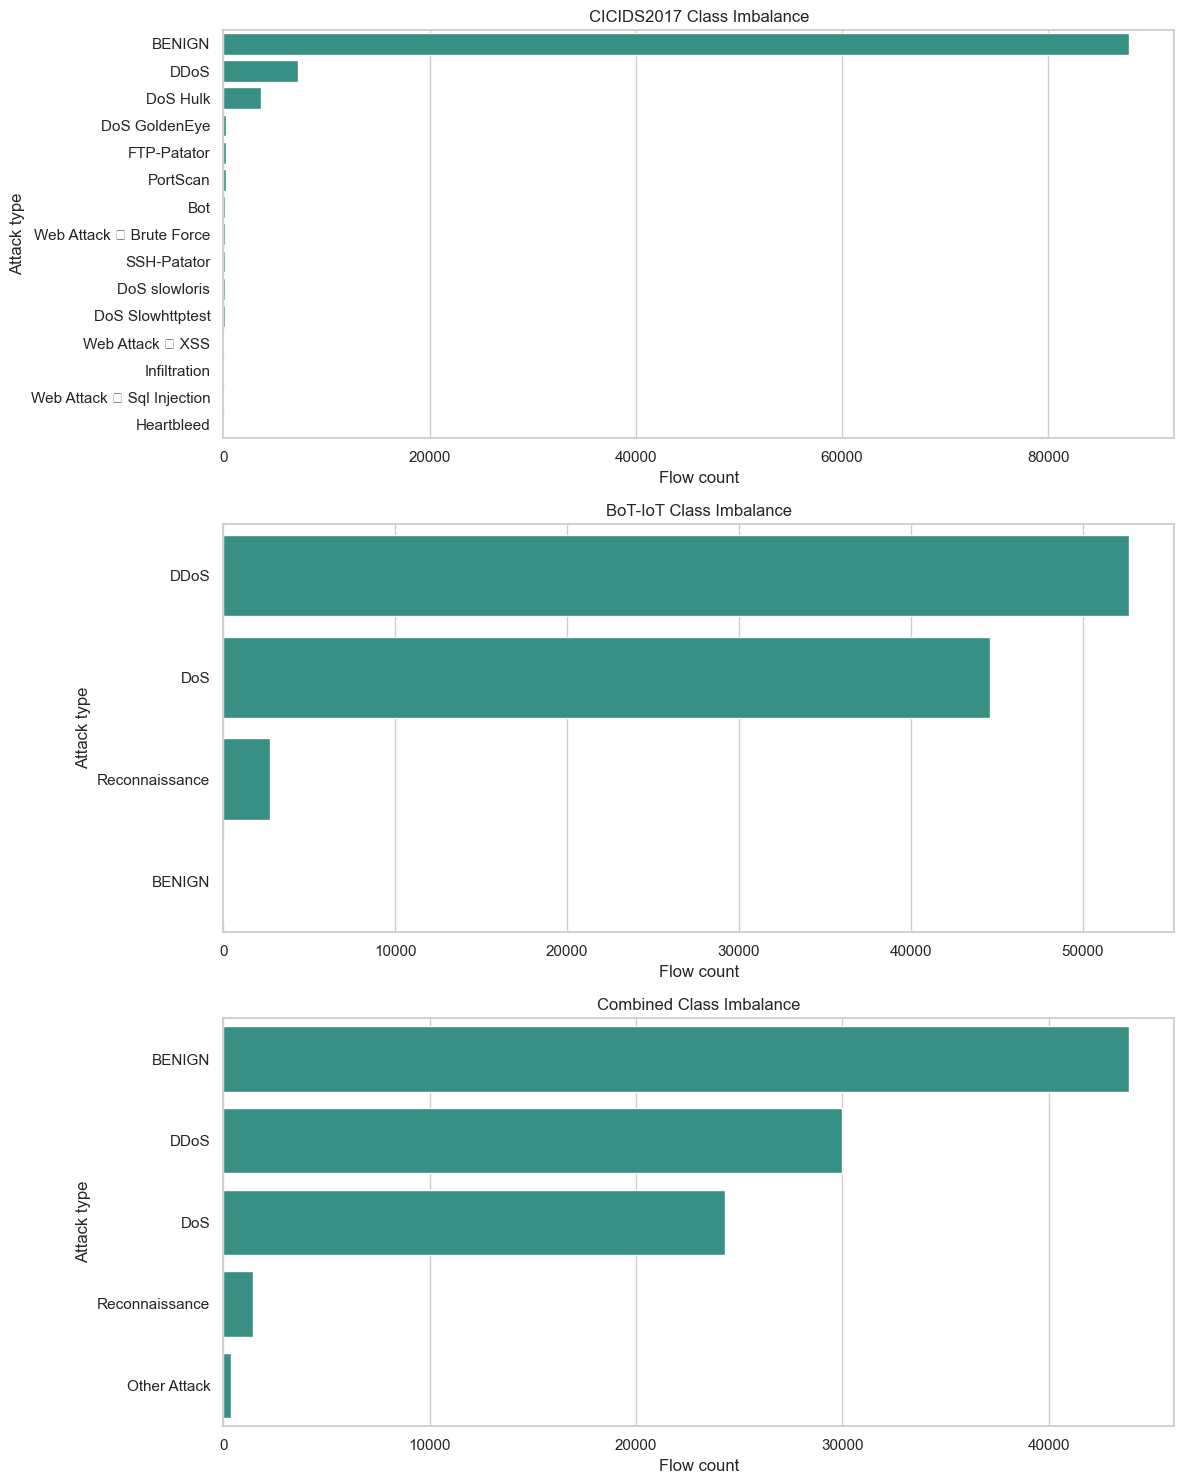

In [3]:
available = [(name, frame) for name, frame in datasets.items() if not frame.empty]
if available:
    figure, axes = plt.subplots(len(available), 1, figsize=(12, 5 * len(available)), squeeze=False)
    for axis, (name, frame) in zip(axes.flat, available):
        label_column = label_for(name, frame)
        counts = frame[label_column].map(clean_label).value_counts()
        sns.barplot(x=counts.values, y=counts.index, color='#2a9d8f', ax=axis)
        axis.set_title(f'{name} Class Imbalance')
        axis.set_xlabel('Flow count')
        axis.set_ylabel('Attack type')
    figure.tight_layout()
    plt.show()

In [4]:
attack_breakdowns = []
for name, frame in available:
    label_column = label_for(name, frame)
    breakdown = frame[label_column].map(clean_label).value_counts(dropna=False).rename_axis('attack_type').reset_index(name='count')
    breakdown['percent'] = breakdown['count'].div(breakdown['count'].sum()).mul(100)
    breakdown.insert(0, 'dataset', name)
    attack_breakdowns.append(breakdown)
if attack_breakdowns:
    display(pd.concat(attack_breakdowns, ignore_index=True))

,dataset,attack_type,count,percent
0,CICIDS2017,BENIGN,87793,87.793
1,CICIDS2017,DDoS,7270,7.270
2,CICIDS2017,DoS Hulk,3650,3.650
3,CICIDS2017,DoS GoldenEye,232,0.232
4,CICIDS2017,FTP-Patator,207,0.207
5,CICIDS2017,PortScan,201,0.201
6,CICIDS2017,Bot,124,0.124
7,CICIDS2017,Web Attack � Brute Force,117,0.117
8,CICIDS2017,SSH-Patator,113,0.113
9,CICIDS2017,DoS slowloris,106,0.106


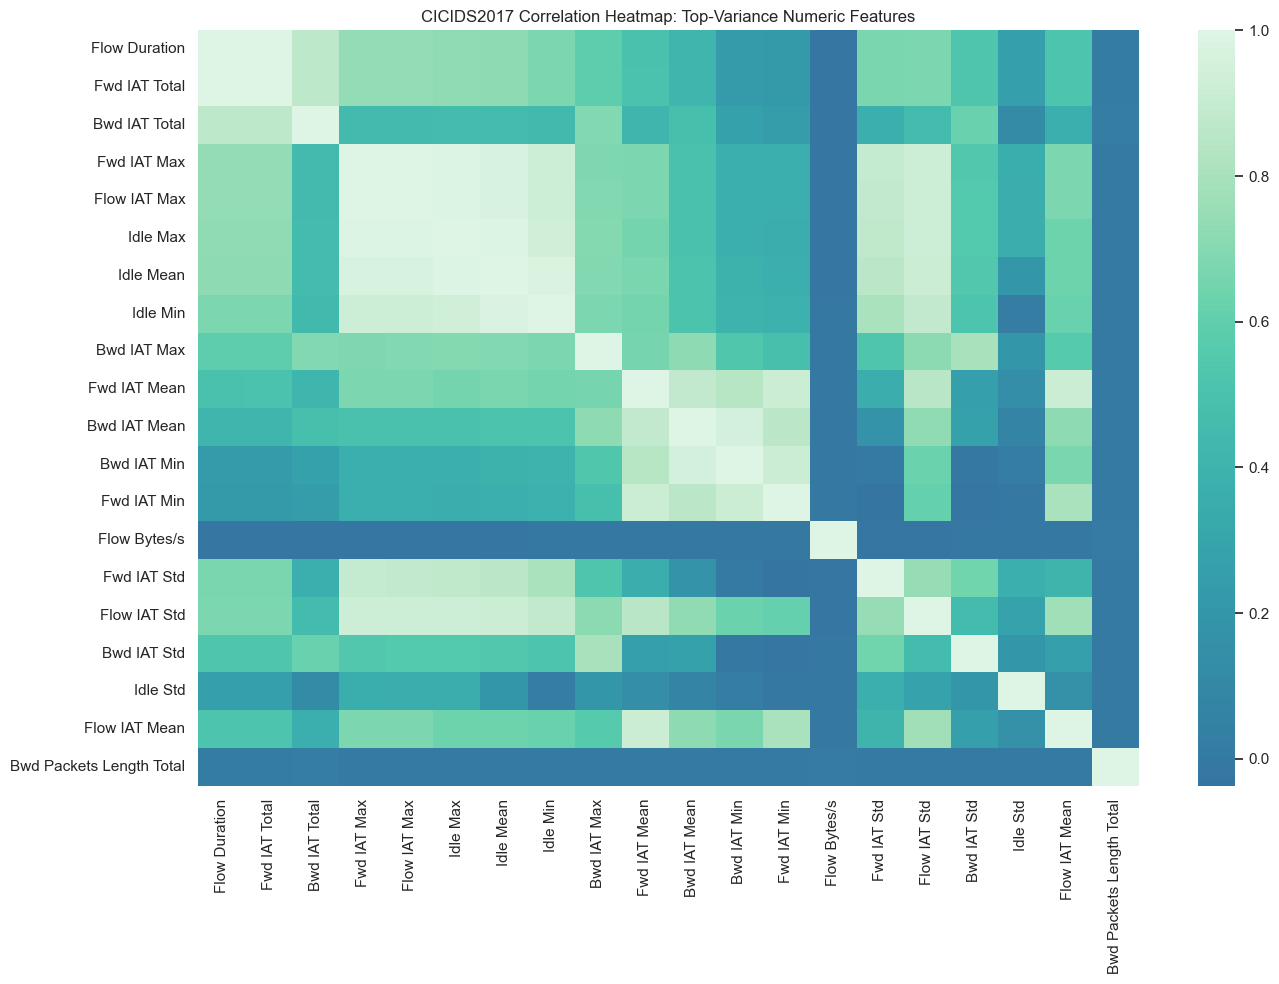

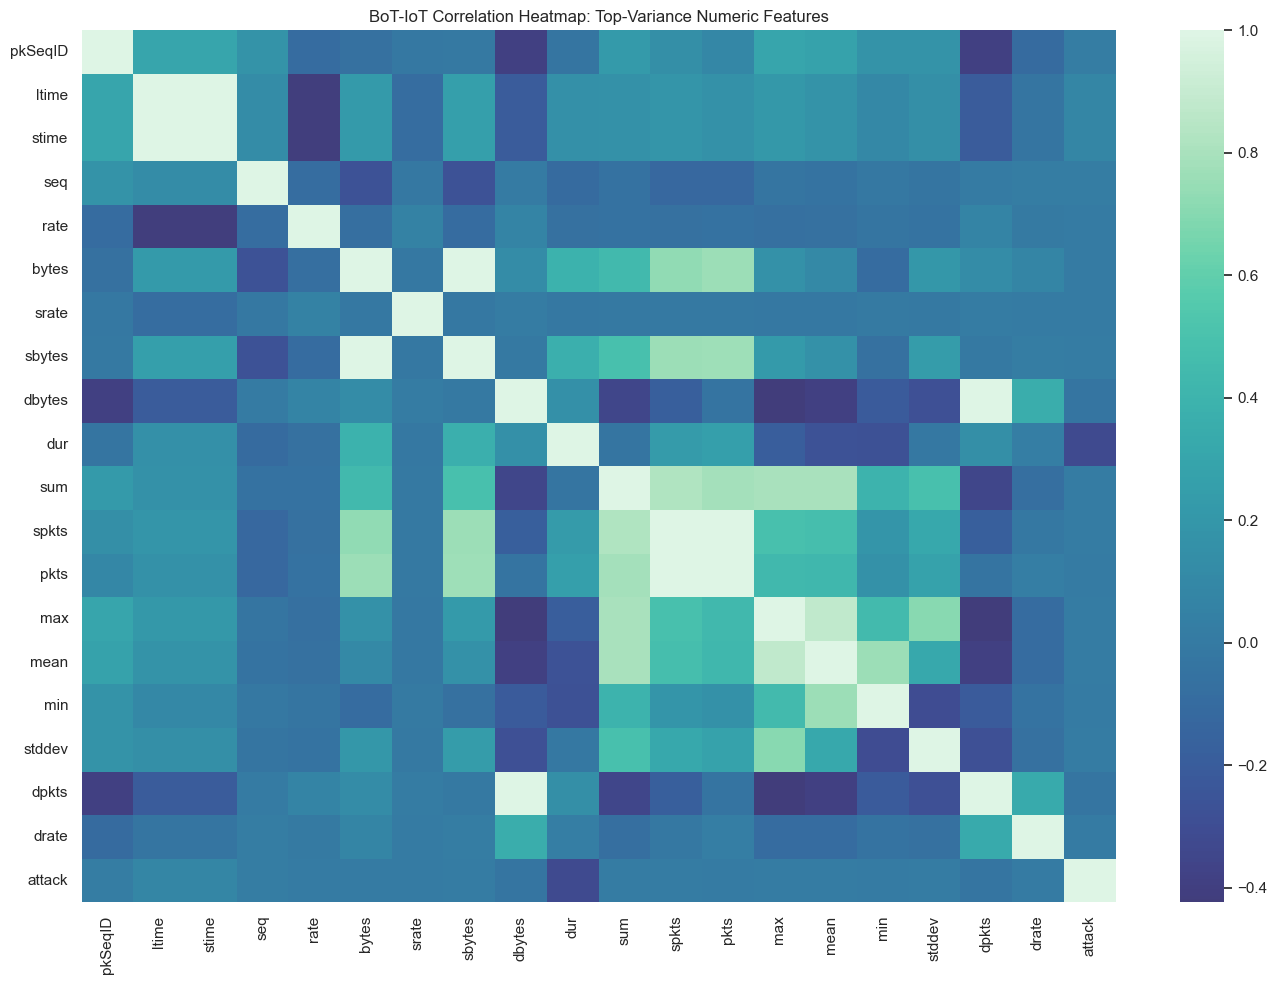

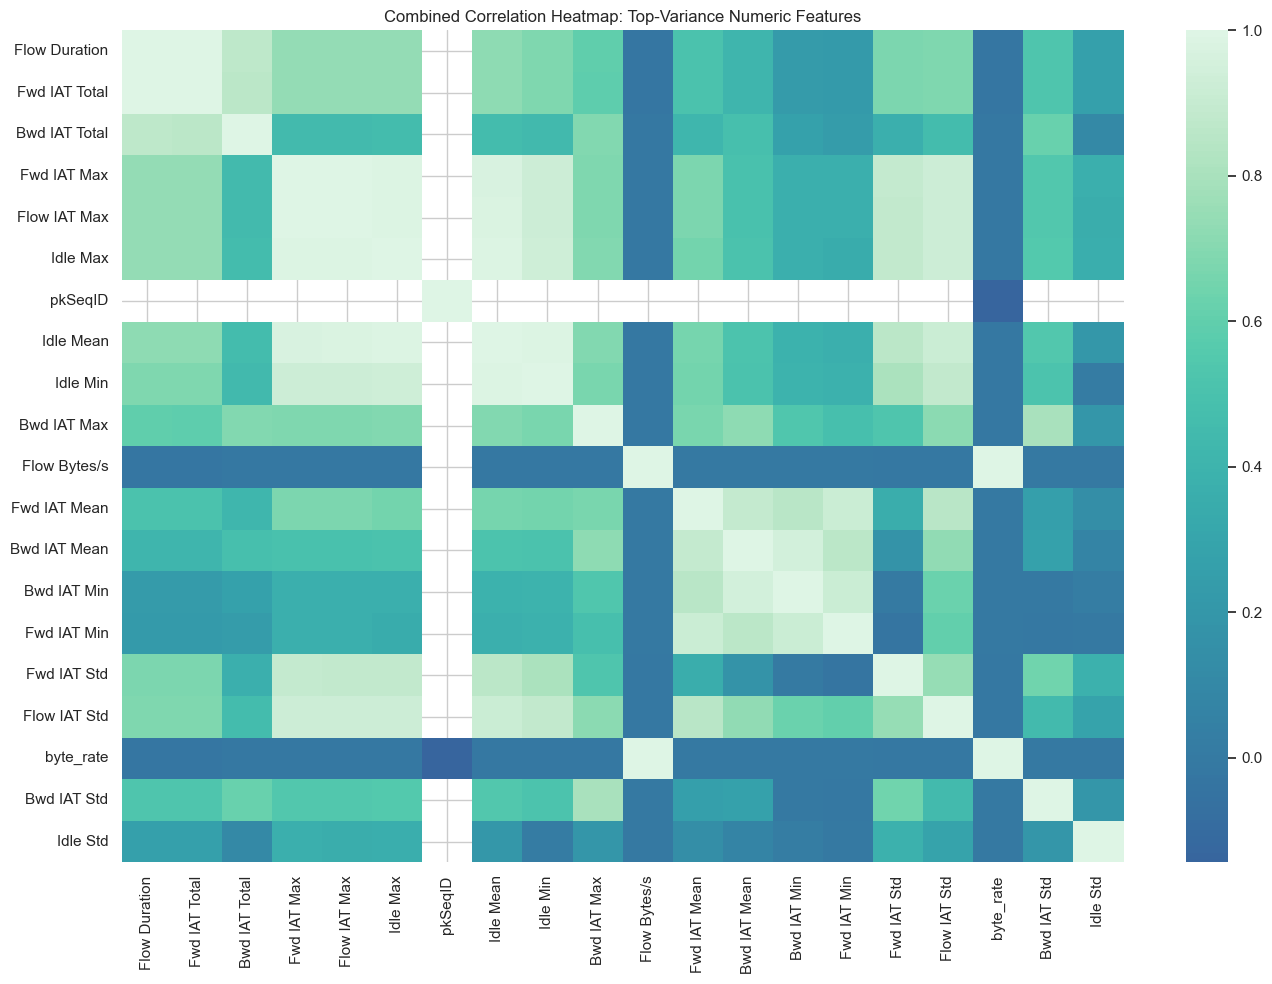

In [5]:
for name, frame in available:
    numeric = frame.select_dtypes(include='number').replace([float('inf'), float('-inf')], pd.NA)
    numeric = numeric.dropna(axis=1, how='all')
    top_columns = numeric.var(numeric_only=True).sort_values(ascending=False).head(20).index
    correlation = numeric[top_columns].corr()
    plt.figure(figsize=(14, 10))
    sns.heatmap(correlation, cmap='mako', center=0, square=False)
    plt.title(f'{name} Correlation Heatmap: Top-Variance Numeric Features')
    plt.tight_layout()
    plt.show()

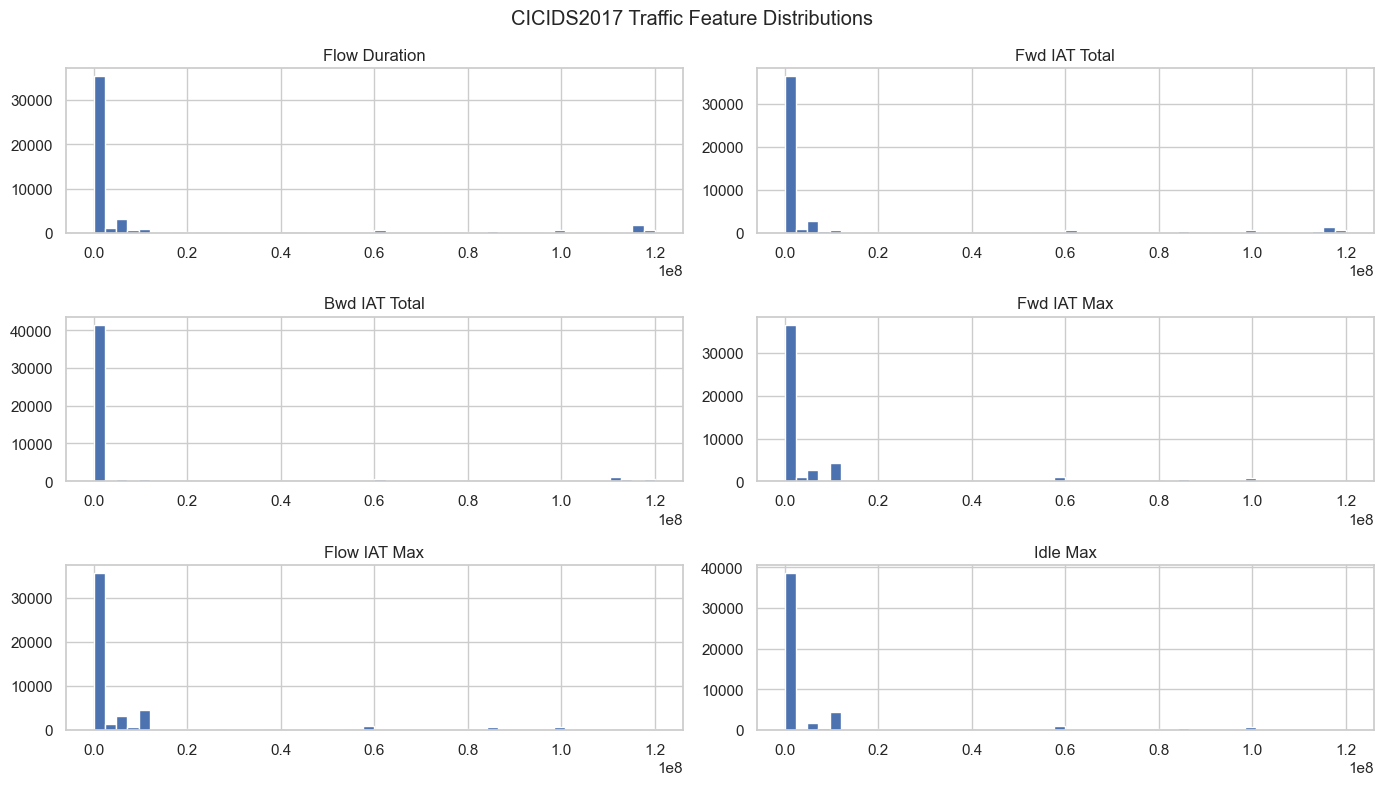

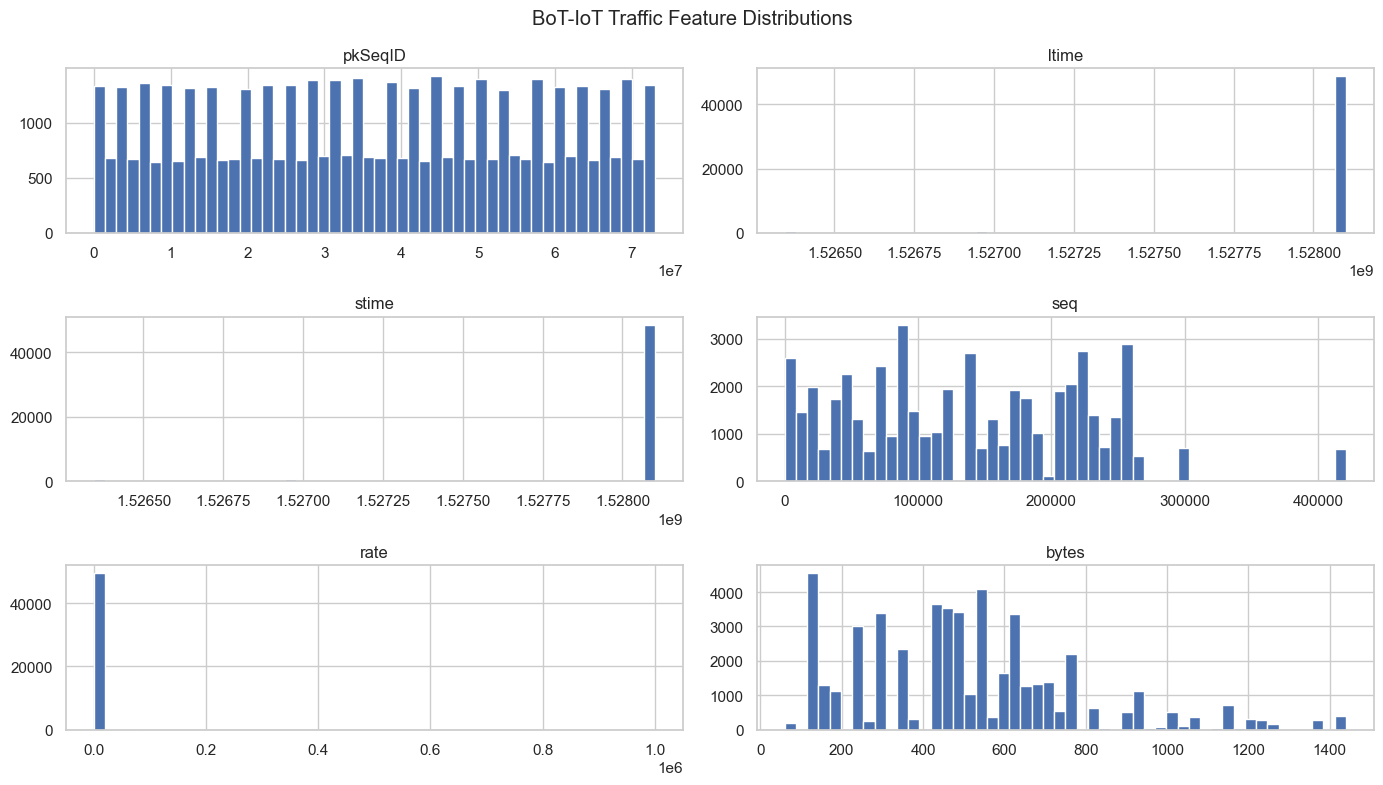

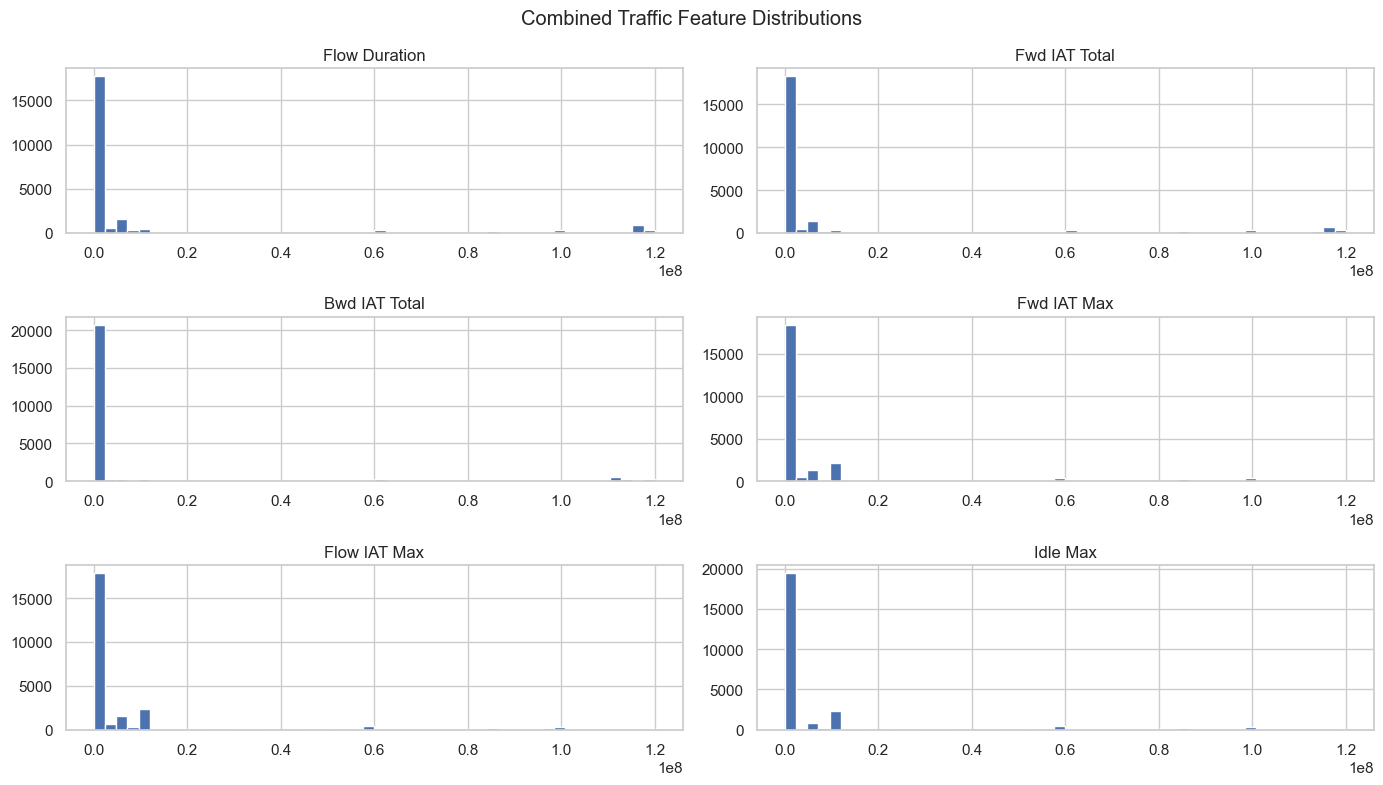

In [6]:
for name, frame in available:
    numeric = frame.select_dtypes(include='number').replace([float('inf'), float('-inf')], pd.NA)
    numeric = numeric.dropna(axis=1, how='all')
    traffic_columns = numeric.var(numeric_only=True).sort_values(ascending=False).head(6).index.tolist()
    if traffic_columns:
        numeric[traffic_columns].sample(min(len(numeric), 50000), random_state=42).hist(figsize=(14, 8), bins=50)
        plt.suptitle(f'{name} Traffic Feature Distributions')
        plt.tight_layout()
        plt.show()